In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

We take our data compiled from our trials. Mass is in grams. The trial data represents the length of the spring in centimeters.

In [21]:
data = {
    'Mass_g': [41, 50, 100, 150, 200, 250, 32, 37, 0], 
    'Trial_1': [5.9, 6.3, 10.1, 13.9, 18.0, 21.8, 5.8, 5.9, 5.6],
    'Trial_2': [5.9, 6.4, 10.2, 14.1, 17.9, 21.9, 5.8, 5.9, 5.6],
    'Trial_3': [6.0, 6.3, 10.1, 14.0, 18.0, 21.7, 5.9, 5.8, 5.7],
    'Trial_4': [5.9, 6.4, 10.1, 14.0, 17.8, 21.9, 5.9, 5.9, 5.8],
    'Trial_5': [6.0, 6.3, 10.2, 13.9, 18.0, 21.8, 5.7, 5.8, 5.7]
}
df = pd.DataFrame(data)
df = df.sort_values(by=["Mass_g"]) # Masses measured in weird order, want to be more organized
print(df)

   Mass_g  Trial_1  Trial_2  Trial_3  Trial_4  Trial_5
8       0      5.6      5.6      5.7      5.8      5.7
6      32      5.8      5.8      5.9      5.9      5.7
7      37      5.9      5.9      5.8      5.9      5.8
0      41      5.9      5.9      6.0      5.9      6.0
1      50      6.3      6.4      6.3      6.4      6.3
2     100     10.1     10.2     10.1     10.1     10.2
3     150     13.9     14.1     14.0     14.0     13.9
4     200     18.0     17.9     18.0     17.8     18.0
5     250     21.8     21.9     21.7     21.9     21.8


Some relevant data:

In [22]:
trial_cols = df.loc[:, 'Trial_1':'Trial_5']
df['Average Length'] = trial_cols.mean(axis=1)
df['Standard Deviation'] = trial_cols.std(axis=1)
df['Standard Error'] = df['Standard Deviation']/np.sqrt(5)
print(df[['Mass_g', 'Average Length', 'Standard Deviation', 'Standard Error']])

   Mass_g  Average Length  Standard Deviation  Standard Error
8       0            5.68            0.083666        0.037417
6      32            5.82            0.083666        0.037417
7      37            5.86            0.054772        0.024495
0      41            5.94            0.054772        0.024495
1      50            6.34            0.054772        0.024495
2     100           10.14            0.054772        0.024495
3     150           13.98            0.083666        0.037417
4     200           17.94            0.089443        0.040000
5     250           21.82            0.083666        0.037417


Now we calculate the appropriate differences. Note that the standard error in the differences for mass $i$ ought not be the standard error of the differences themselves, but the quadratic mean of the standard error for mass i and the standard error for mass 0. We manually set the difference SE for Mass$_g$= 0 to be its own standard error.

In [23]:
df['Average Difference'] = df['Average Length'] - df.at[8, 'Average Length']
df['Difference SE'] = np.sqrt(df['Standard Error']**2 + df.at[8, 'Standard Error']**2)
df.at[8,'Difference SE'] = df.at[8, 'Standard Error']
print(df[['Mass_g', 'Average Difference', 'Difference SE']])

   Mass_g  Average Difference  Difference SE
8       0                0.00       0.037417
6      32                0.14       0.052915
7      37                0.18       0.044721
0      41                0.26       0.044721
1      50                0.66       0.044721
2     100                4.46       0.044721
3     150                8.30       0.052915
4     200               12.26       0.054772
5     250               16.14       0.052915


We now calculate $k$ independently for each of the mass trials, including a standard error:

In [100]:
df['k'] = df['Mass_g'] * 980 / df['Average Difference']
df['SE_k'] = df['k'] * np.sqrt((0.5/df['Mass_g'])**2 + (df['Difference SE']/df['Average Difference'])**2)
print(df[['Mass_g', 'k', 'SE_k']])
print(df[df['Mass_g'] > 40]['k'].mean())
print(np.sqrt((((df[df['Mass_g'] > 40]['SE_k'])**2).mean())))

   Mass_g              k          SE_k
8       0            NaN           NaN
6      32  224000.000000  84736.355834
7      37  201444.444444  50123.251915
0      41  154538.461538  26648.149072
1      50   74242.424242   5085.128192
2     100   21973.094170    246.201587
3     150   17710.843373    127.414246
4     200   15986.949429     81.844860
5     250   15179.677819     58.295847
49938.57509548391
11076.020075542563


Plotting this as a scatterplot:

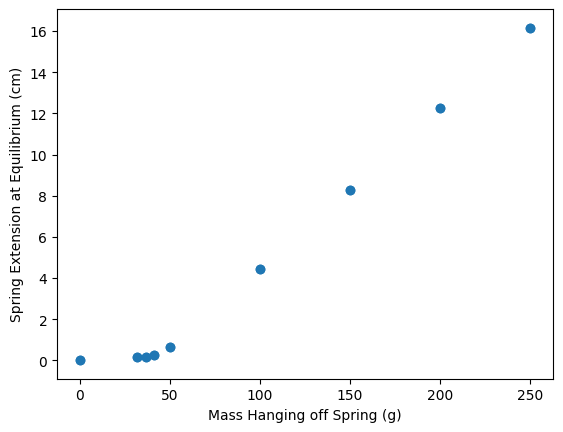

In [25]:
x = df['Mass_g'].tolist()
y = df['Average Difference'].tolist()
err = (2*df['Difference SE']).tolist()
plt.xlabel('Mass Hanging off Spring (g)')
plt.ylabel('Spring Extension at Equilibrium (cm)')
plt.scatter(x,y)
plt.errorbar(x, y, yerr=err, fmt='o')
plt.show()

This follows roughly the expected shape, slower towards the beginning and tending towards linear as the mass increases. I'm conjecturing that the error bars aren't showing because the errors are very small, and fit inside the scatterplot dots.

We proceed on our linear regression. We begin with direct proportionality.

We have $mg = k \Delta x$, so we can find the value of $k$ by plotting the points as $(m_ig, \Delta x_i)$ and taking the inverse of the slope.

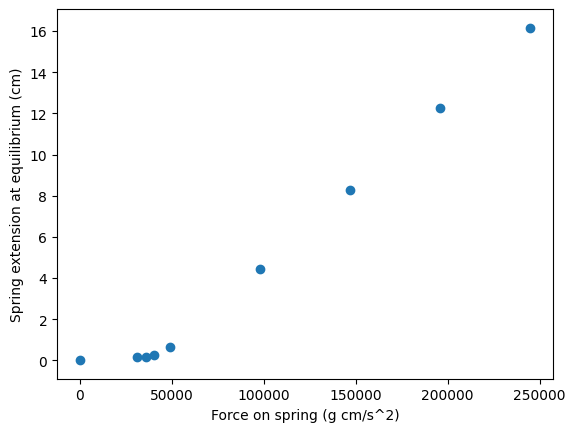

In [26]:
x = (df['Mass_g']*980.0).tolist() # We use 980.0 cm/s^2 for g
y = (df['Average Difference']).tolist() # Technically redundant, done for clarity
plt.clf()
plt.xlabel('Force on spring (g cm/s^2)')
plt.ylabel('Spring extension at equilibrium (cm)')
plt.scatter(x,y)
plt.errorbar(x,y,yerr=err, fmt='.')
plt.show()

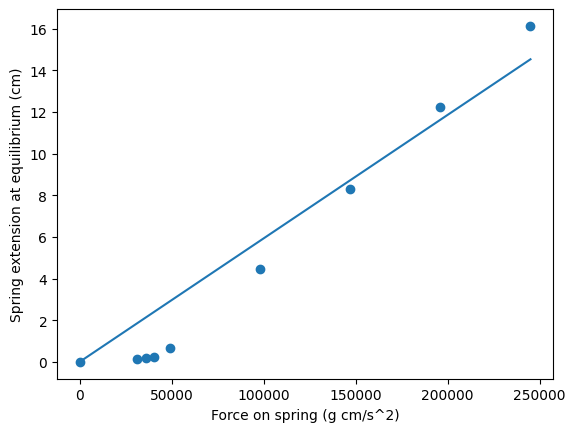

In [27]:
model = LinearRegression(fit_intercept=False)
x = np.array(x).reshape(-1,1)
y = np.array(y)
model.fit(x,y)
y_pred = model.predict(x)
plt.xlabel('Force on spring (g cm/s^2)')
plt.ylabel('Spring extension at equilibrium (cm)')
plt.scatter(x,y)
plt.plot(x, y_pred)
plt.show()

In [28]:
# The slope is...
print(f'beta_1 = {model.coef_[0]}')

beta_1 = 5.9338694439166897e-05


In [29]:
# Which gives us k = ...
print(f'k = {1/model.coef_[0]}')

k = 16852.409872704302


In [30]:
# Some other goodies:
print(f'Linear Model: y_pred = {model.coef_[0]}x')
print(f'R^2: {r2_score(y, y_pred)}')

Linear Model: y_pred = 5.9338694439166897e-05x
R^2: 0.9287903632741635


Thus, the value of $k$ is approximately $16,852 g/s^2$, or $16.852 kg/s^2$. However, this model assumes direct proportionality, which may not be...the best...as the linear model itself does not accurately describe small values of $\Delta L$. We will proceed to redo this calculation, now using a model with a nonzero intercept.

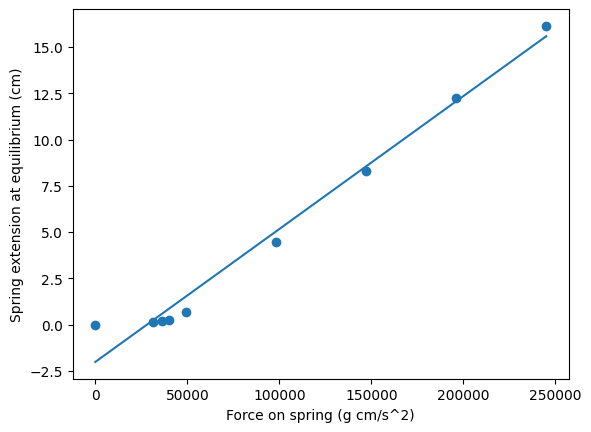

In [31]:
new_model = LinearRegression()
new_model.fit(x,y)
y_pred_new = new_model.predict(x)
plt.xlabel('Force on spring (g cm/s^2)')
plt.ylabel('Spring extension at equilibrium (cm)')
plt.scatter(x,y)
plt.plot(x,y_pred_new)
plt.show()

Interesting! Now we have a nonzero (and in fact, negative) intercept. This reflects the linear modeling limitations emergent from the non-linear behavior of the spring at small extensions. Finding the value of $k$ given this:

In [32]:
print(f'k = {1/new_model.coef_[0]}')

k = 13921.285529029103


Which is quite different from our previous estimation. This gives a value of $k = 13.921 kg/s^2$. I find this alarming.

In [33]:
# Goodies:
print(f'Linear Model: y_pred = {new_model.intercept_} + {new_model.coef_[0]}x')
print(f'R^2: {r2_score(y, y_pred_new)}')

Linear Model: y_pred = -2.015598448086858 + 7.183244664544582e-05x
R^2: 0.979856877393169


This is a much better model considering all of our data, with an $R^2$ of $0.980$.

The high deviations made me wonder, out of curiosity: we have reason to believe that below 50 grams, the activity of the spring will be nonlinear, and we should not try to model it with linear regression. Let's remodel, throwing out this data.

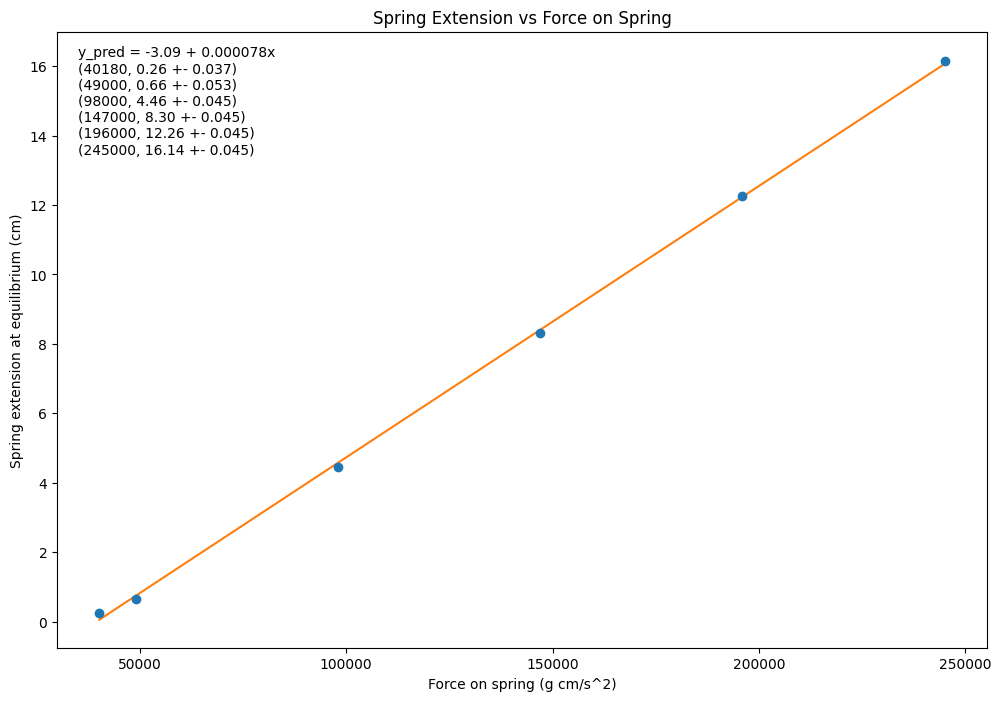

In [93]:
x_new = (df['Mass_g']*980.0).tolist()
y_new = (df['Average Difference']).tolist()
x_new = [item for item in x_new if item >= 41*980.0]
y_new = [y_new[i] for i in range(len(y_new)) if i >= len(y_new) - len(x_new)]
err_new = (df['Difference SE']).tolist()
err_new = [err_new[i] for i in range(len(y_new)) if i >= len(y_new) - len(x_new)]
eqn = f'y_pred = {fifty_model.intercept_:.2f} + {fifty_model.coef_[0]:.6f}x \n'
stat_text = ''
for i in range(len(x_new)):
    stat_text += f'({x_new[i]:.0f}, {y_new[i]:.2f} +- {err_new[i]:.3f}) \n'
x_new = np.array(x_new).reshape(-1,1)
y_new = np.array(y_new)
err_new = np.array(err_new)

fifty_model = LinearRegression()
fifty_model.fit(x_new, y_new)
y_pred_fifty = fifty_model.predict(x_new)
plt.figure(figsize=(12,8))
plt.xlabel('Force on spring (g cm/s^2)')
plt.ylabel('Spring extension at equilibrium (cm)')
plt.title('Spring Extension vs Force on Spring')
plt.errorbar(x_new, y_new, yerr=err_new, fmt='o')
plt.plot(x_new, y_pred_fifty)
plt.text(35000, 13, eqn+stat_text)
plt.show()

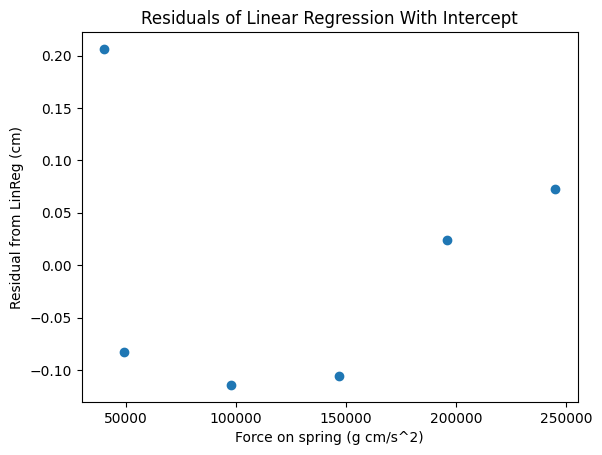

In [99]:
residuals = y_new - y_pred_fifty
plt.xlabel('Force on spring (g cm/s^2)')
plt.ylabel('Residual from LinReg (cm)')
plt.title('Residuals of Linear Regression With Intercept')
plt.scatter(x_new, residuals)
plt.show()

That looks...really good. I cooked with that one. Calculating $k$:

In [39]:
# k is inverse of slope, more or less
print(f'k = {1/fifty_model.coef_[0]}')

k = 12790.339227706627


Giving us $k \approx 12.790 kg/s^2$.

In [103]:
# goodies
print(f'Linear Model: y_pred = {fifty_model.intercept_} + {fifty_model.coef_[0]}x')
print(f'R^2: {r2_score(y_new, y_pred_fifty)}')
residuals = y_new - y_pred_fifty
alpha_CU = np.sqrt(np.sum(residuals**2) / (4))
sum_x_squared = np.sum(x_new**2)
alpha_m = alpha_CU / np.sqrt(sum_x_squared)
print(f"Common Uncertainty (alpha_CU): {alpha_CU}")
print(f"Uncertainty in Slope (alpha_m): {alpha_m}")
print(f'SE_k = {(1/fifty_model.coef_[0])**2 * alpha_m}')

Linear Model: y_pred = -3.087780043456461 + 7.818400921171698e-05x
R^2: 0.9996121895174974
Common Uncertainty (alpha_CU): 0.14096974547309934
Uncertainty in Slope (alpha_m): 3.855758846160995e-07
SE_k = 63.077429924428905


A very high $R^2$, but a somewhat concerning intercept, implying that perhaps the linear model is very bad for very small values of $\Delta L$.

And a direct proportionality model:

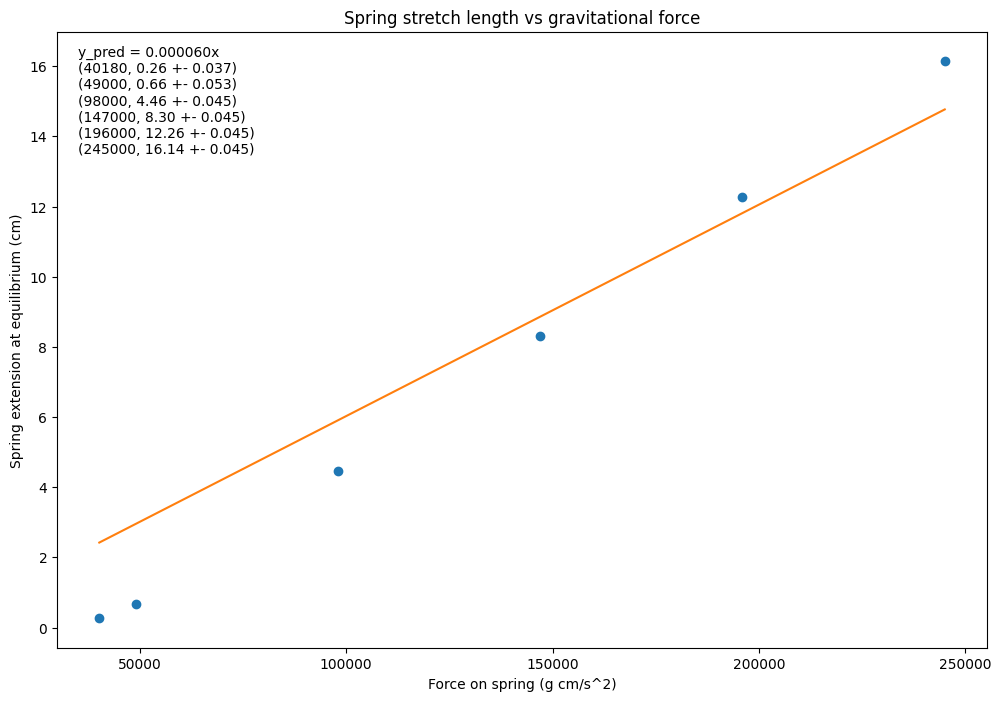

In [97]:
new_direct_prop = LinearRegression(fit_intercept=False)
new_direct_prop.fit(x_new, y_new)
y_pred_new_direct = new_direct_prop.predict(x_new)
plt.figure(figsize=(12,8))
plt.xlabel('Force on spring (g cm/s^2)')
plt.ylabel('Spring extension at equilibrium (cm)')
plt.title('Spring stretch length vs gravitational force')
plt.errorbar(x_new, y_new, yerr = err_new, fmt='o')
plt.text(35000, 13.05, f'y_pred = {new_direct_prop.coef_[0]:.6f}x \n'+stat_text)
plt.plot(x_new, y_pred_new_direct)
plt.show()

In [47]:
# k is inverse of slope, more or less
print(f'k = {1/new_direct_prop.coef_[0]}')
print(f'Linear Model: y_pred = {new_direct_prop.coef_[0]}x')
print(f'R^2: {r2_score(y_new, y_pred_new_direct)}')

k = 16590.0049381755
Linear Model: y_pred = 6.027725752503458e-05x
R^2: 0.9296267768106806


Expectedly worse.

In [104]:
residuals = y_new - y_pred_new_direct
alpha_CU = np.sqrt(np.sum(residuals**2) / (5))
sum_x_squared = np.sum(x_new**2)
alpha_m = alpha_CU / np.sqrt(sum_x_squared)

print(f"Common Uncertainty (alpha_CU): {alpha_CU}")
print(f"Uncertainty in Slope (alpha_m): {alpha_m}")
print(f'Uncertainty in k: {(1/new_direct_prop.coef_[0])**2 * alpha_m}')

Common Uncertainty (alpha_CU): 1.6984972910658278
Uncertainty in Slope (alpha_m): 4.645674810030262e-06
Uncertainty in k: 1278.6210123702103


Residual Plot:

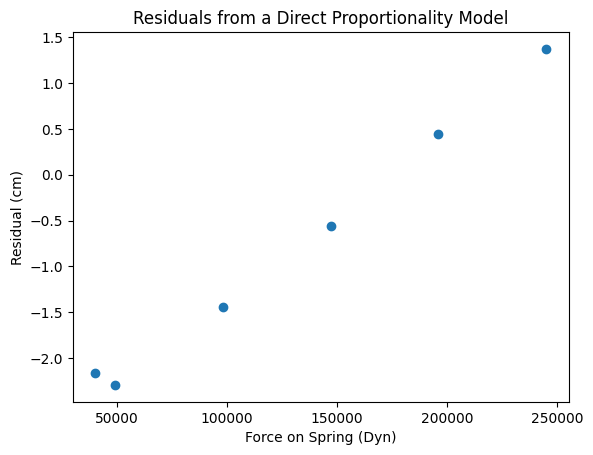

In [60]:
plt.scatter(x_new, residuals)
plt.title('Residuals from a Direct Proportionality Model')
plt.xlabel('Force on Spring (Dyn)')
plt.ylabel('Residual (cm)')
plt.show()